# Tennis Match Predictor

Predicting the winner of ATP matches from informaton known **before** the match.
Data: 2000-2024 ATP seasons (Jeff Sackmann, via the guillemservera Kaggle mirror).

## 1. Load the Data

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier

In [27]:
df = pd.read_csv("atp_matches_2000_2024.csv")
print(df.shape)
df.head()

C:\Users\rombe\AppData\Local\Temp\ipykernel_7424\2197547105.py:1: DtypeWarning: Columns (8,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("atp_matches_2000_2024.csv")


(73247, 49)


,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,2000-301,Auckland,Hard,32,A,20000110,1,103163,1.0,NaN,...,55.0,39.0,29.0,17.0,4.0,7.0,11.0,1612.0,63.0,595.0
1,2000-301,Auckland,Hard,32,A,20000110,2,102607,NaN,Q,...,32.0,25.0,18.0,12.0,3.0,6.0,211.0,157.0,49.0,723.0
2,2000-301,Auckland,Hard,32,A,20000110,3,103252,NaN,NaN,...,33.0,20.0,7.0,8.0,7.0,11.0,48.0,726.0,59.0,649.0
3,2000-301,Auckland,Hard,32,A,20000110,4,103507,7.0,NaN,...,43.0,29.0,14.0,10.0,6.0,8.0,45.0,768.0,61.0,616.0
4,2000-301,Auckland,Hard,32,A,20000110,5,102103,NaN,Q,...,46.0,34.0,18.0,12.0,5.0,9.0,167.0,219.0,34.0,873.0


## 2. Clean the Data

In [28]:
df["tourney_date"] = pd.to_datetime(df["tourney_date"], format="%Y%m%d")
df["year"] = df["tourney_date"].dt.year
df["month"] = df["tourney_date"].dt.month

df[["tourney_date", "year", "month"]].head()

,tourney_date,year,month
0,2000-01-10,2000,1
1,2000-01-10,2000,1
2,2000-01-10,2000,1
3,2000-01-10,2000,1
4,2000-01-10,2000,1


In [29]:
df.isna().sum().sort_values(ascending=False).head(10)

winner_entry    64018
loser_entry     58240
loser_seed      56389
winner_seed     42803
minutes          7938
l_df             6469
l_ace            6469
l_1stIn          6469
l_1stWon         6469
l_2ndWon         6469
dtype: int64

In [30]:
print("Before: ", df.shape)

df = df.dropna(subset=["surface", "winner_rank", "loser_rank"])

df["winner_ht"] = df["winner_ht"].fillna(df["winner_ht"].median())
df["loser_ht"] = df["loser_ht"].fillna(df["loser_ht"].median())

print("After: ", df.shape)

Before:  (73247, 51)
After:  (71465, 51)


## Explore the Data (charts)

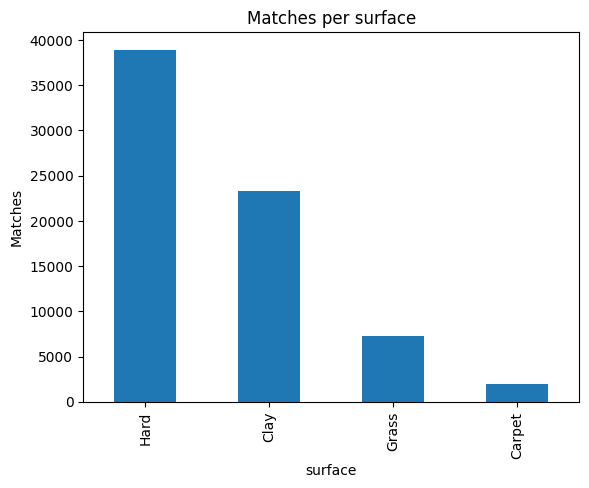

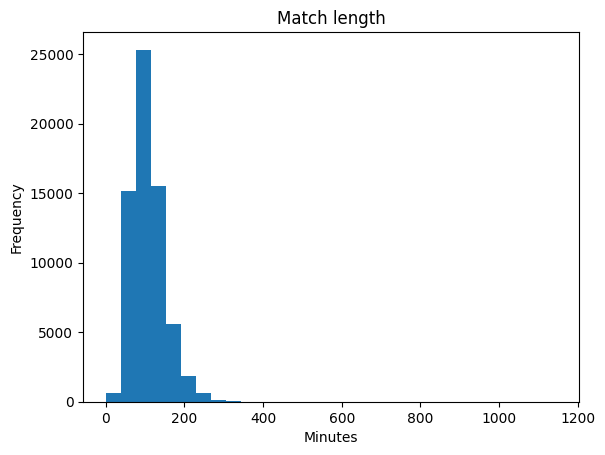

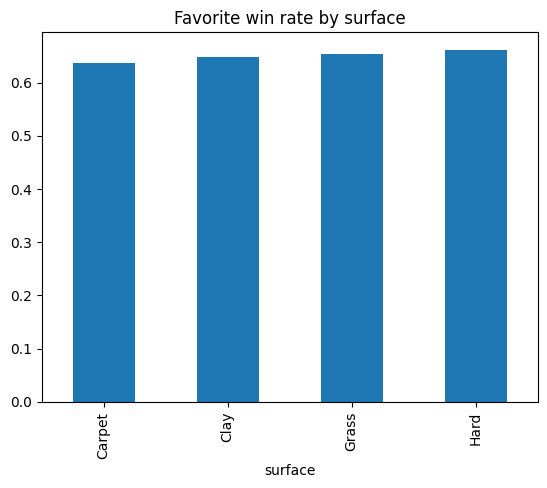

In [31]:
df["surface"].value_counts().plot(kind="bar", title="Matches per surface")
plt.ylabel("Matches")
plt.show()

df["minutes"].plot(kind="hist", bins=30, title="Match length")
plt.xlabel("Minutes")
plt.show()

df["favorite_won"] = df["winner_rank"] < df["loser_rank"]
df.groupby("surface")["favorite_won"].mean().plot(kind="bar", title="Favorite win rate by surface")
plt.show()

## 3. Build Features

In [32]:
rng = np.random.default_rng(seed=42)
df["winner_is_A"] = rng.random(len(df)) < 0.5
df["target"] = df["winner_is_A"].astype(int)
df["target"].value_counts(normalize=True)

target
0    0.502666
1    0.497334
Name: proportion, dtype: float64

In [33]:
def a_minus_b(winner_col, loser_col):
    a = np.where(df["winner_is_A"], df[winner_col], df[loser_col])
    b = np.where(df["winner_is_A"], df[loser_col], df[winner_col])
    return a - b

df["rank_diff"]   = a_minus_b("winner_rank", "loser_rank")
df["points_diff"] = a_minus_b("winner_rank_points", "loser_rank_points")
df["age_diff"]    = a_minus_b("winner_age", "loser_age")
df["height_diff"] = a_minus_b("winner_ht", "loser_ht")

# drop any rows still missing a feature value, so the models never see a gap
feature_cols = ["rank_diff", "points_diff", "age_diff", "height_diff"]
df = df.dropna(subset=feature_cols + ["target"])

df[["target"] + feature_cols].head()

,target,rank_diff,points_diff,age_diff,height_diff
0,0,52.0,-1017.0,9.4,-8.0
1,1,162.0,-566.0,0.2,7.0
2,0,11.0,-77.0,5.2,-2.0
3,0,16.0,-152.0,-1.5,2.0
4,1,133.0,-654.0,3.6,-5.0


## 4. Save the Clean Dataset

In [34]:
df.to_csv("atp_2000_2024_clean", index=False)
print("saved", df.shape)

saved (71463, 58)


## Train / Test Split

In [35]:
df_sorted = df.sort_values("tourney_date")
cut = int(len(df_sorted) *  0.8)
train = df_sorted.iloc[:cut]
test = df_sorted.iloc[cut:]
print("Train:", train.shape[0], " Test:", test.shape[0])

Train: 57170  Test: 14293


## 5. Baseline Model

In [36]:
baseline_pred = (test["rank_diff"] < 0).astype(int)
baseline_acc = accuracy_score(test["target"], baseline_pred)
print("Baseline accuracy:", round(baseline_acc, 3))

Baseline accuracy: 0.637


## 6. Train a Model

In [37]:
feature_cols = ["rank_diff", "points_diff", "age_diff", "height_diff"]
X_train, y_train = train[feature_cols], train["target"]
X_test, y_test = test[feature_cols], test["target"]

In [38]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)

logreg_acc = accuracy_score(y_test, logreg_pred)
print("Logistic regression:", round(logreg_acc, 3))

Logistic regression: 0.642


In [39]:
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)

tree_acc = accuracy_score(y_test, tree_pred)
print("Decision tree:", round(tree_acc, 3))

Decision tree: 0.637


In [40]:
forest = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
forest.fit(X_train, y_train)
forest_pred = forest.predict(X_test)

forest_acc = accuracy_score(y_test, forest_pred)
print("Random forest:", round(forest_acc, 3))

Random forest: 0.641


In [41]:
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

In [42]:
gb = GradientBoostingClassifier(max_depth=3, random_state=42).fit(X_train, y_train)
gb_acc = accuracy_score(y_test, gb.predict(X_test))

knn = KNeighborsClassifier(n_neighbors=15).fit(X_train_s, y_train)
knn_acc = accuracy_score(y_test, knn.predict(X_test_s))

svm = LinearSVC(max_iter=5000).fit(X_train_s, y_train)
svm_acc = accuracy_score(y_test, svm.predict(X_test_s))

nn = MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=300, random_state=42).fit(X_train_s, y_train)
nn_acc = accuracy_score(y_test, nn.predict(X_test_s))

print("boosting", round(gb_acc,3), "KNN", round(knn_acc,3), "SVM", round(svm_acc,3), "NN", round(nn_acc,3))

boosting 0.641 KNN 0.629 SVM 0.642 NN 0.642


## 7. Evaluate

In [43]:
results = pd.DataFrame({
    "model": ["baseline (favorite wins)", "logistic regression", "decision tree"],
    "accuracy": [baseline_acc, logreg_acc, tree_acc]
})
results

,model,accuracy
0,baseline (favorite wins),0.636605
1,logistic regression,0.642342
2,decision tree,0.636885


In [44]:
import os
os.makedirs("charts", exist_ok=True)

# 1) favorite win rate by surface
ax = df.groupby("surface")["favorite_won"].mean().plot(kind="bar", title="Favorite win rate by surface")
ax.set_ylabel("share won by favorite")
ax.figure.savefig("charts/favorite_win_rate.png", bbox_inches="tight", dpi=120)
ax.figure.clear()

# 2) model comparison
ax2 = results.set_index("model")["accuracy"].plot(kind="barh", title="Model accuracy vs baseline")
ax2.set_xlabel("accuracy")
ax2.figure.savefig("charts/model_comparison.png", bbox_inches="tight", dpi=120)
ax2.figure.clear()

print("saved:", os.listdir("charts"))

saved: ['favorite_win_rate.png', 'model_comparison.png']


<Figure size 640x480 with 0 Axes>

In [45]:
print(confusion_matrix(y_test, logreg_pred))
print(classification_report(y_test, logreg_pred, digits=3))

[[4699 2499]
 [2613 4482]]
              precision    recall  f1-score   support

           0      0.643     0.653     0.648      7198
           1      0.642     0.632     0.637      7095

    accuracy                          0.642     14293
   macro avg      0.642     0.642     0.642     14293
weighted avg      0.642     0.642     0.642     14293



In [46]:
pd.Series(tree.feature_importances_, index=feature_cols).sort_values(ascending=False)

points_diff    0.923636
rank_diff      0.076364
age_diff       0.000000
height_diff    0.000000
dtype: float64

In [47]:
X_all = df[feature_cols]
y_all = df["target"]

for name, mdl in [
    ("Logistic regression", LogisticRegression(max_iter=1000)),
    ("Decision tree", DecisionTreeClassifier(max_depth=4, random_state=42)),
    ("Random forest", RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1))
]:
    s = cross_val_score(mdl, X_all, y_all, cv=5)
    print(f"{name:22} {s.mean():.3f} +/- {s.std():.3f}")

Logistic regression    0.657 +/- 0.015
Decision tree          0.655 +/- 0.016
Random forest          0.658 +/- 0.014


## Experiment: Does Adding Features Help?

In [48]:
surface_cols = pd.get_dummies(df["surface"], prefix="surface")
X_more = pd.concat([df[feature_cols], surface_cols, df[["best_of"]]], axis=1)

Xm_train, Xm_test = X_more.iloc[:cut], X_more.iloc[cut:]
more_acc = accuracy_score(y_test, LogisticRegression(max_iter=1000).fit(Xm_train, y_train).predict(Xm_test))

print("4 features:          ", round(logreg_acc, 3))
print("with surface+best_of:", round(more_acc, 3))

4 features:           0.642
with surface+best_of: 0.498


In [49]:
df.to_csv("atp_2000_2024_model_ready.csv", index=False)
print("saved", df.shape)

saved (71463, 58)
